In [128]:
import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, PolynomialFeatures, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, accuracy_score, confusion_matrix
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans

import warnings
warnings.filterwarnings('ignore')

In [129]:
df = pd.read_pickle("cleaned_online_retail.pkl")
print(df.shape)
df.head()

(406309, 8)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


# **STEP 3 : FEATURE ENGINEERING**

In [130]:
# adding a new feature as 'Sales'
df['Sales'] = df['Quantity'] * df['Price']
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Sales
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0


In [131]:
# creating a new df with unique coustomer id
unique_df = df.groupby(by="Customer ID", as_index=False).agg(
        TotalSale = ("Sales", "sum"),
        Frequency = ("Invoice", "nunique"),
        LastInvoiceDate = ("InvoiceDate", "max")
    )


# as_index = False means we dont want to make customer id as index

unique_df.head()

,Customer ID,TotalSale,Frequency,LastInvoiceDate
0,12346.0,169.36,2,2010-06-28 13:53:00
1,12347.0,1323.32,2,2010-12-07 14:57:00
2,12348.0,221.16,1,2010-09-27 14:59:00
3,12349.0,2221.14,2,2010-10-28 08:23:00
4,12351.0,300.93,1,2010-11-29 15:23:00


In [132]:
# copying the unique_df into a new dataframe 

data = unique_df.copy()

unique_df.describe()

,Customer ID,TotalSale,Frequency,LastInvoiceDate
count,4285.000000,4285.000000,4285.000000,4285
mean,15356.806768,2024.126801,4.426138,2010-09-11 00:06:10.431738624
min,12346.000000,1.550000,1.000000,2009-12-01 10:49:00
25%,13891.000000,307.560000,1.000000,2010-07-27 14:39:00
50%,15362.000000,702.900000,2.000000,2010-10-19 12:10:00
75%,16840.000000,1704.290000,5.000000,2010-11-22 11:24:00
max,18287.000000,349164.350000,183.000000,2010-12-09 20:01:00
std,1699.839258,8813.945538,7.938017,NaN


In [133]:
# finding day and month from the newest date in the data

oldest_invoice_date = data['LastInvoiceDate'].max()

print("OLDERST DATE : ", oldest_invoice_date)
print()

delta = oldest_invoice_date - data['LastInvoiceDate']

# 1. Total Days
data['RecencyInDays'] = delta.dt.days

# 2. Total Months (Approximate: 30.44 days per month)
data['RecencyInMonths'] = delta.dt.days / 30.44

# 3. Total Years (Approximate: 365.25 days per year)
# data['RecencyInYears'] = delta.dt.days / 365.25

# print(data['RecencyInYears'].max())

data.head()


OLDERST DATE :  2010-12-09 20:01:00



,Customer ID,TotalSale,Frequency,LastInvoiceDate,RecencyInDays,RecencyInMonths
0,12346.0,169.36,2,2010-06-28 13:53:00,164,5.387648
1,12347.0,1323.32,2,2010-12-07 14:57:00,2,0.065703
2,12348.0,221.16,1,2010-09-27 14:59:00,73,2.398160
3,12349.0,2221.14,2,2010-10-28 08:23:00,42,1.379763
4,12351.0,300.93,1,2010-11-29 15:23:00,10,0.328515


In [134]:
# finding the days and months of the data based on todays date

today = pd.to_datetime('today')

data['RecencyInDays'] = (today - data['LastInvoiceDate']).dt.days
data['RecencyInMonths'] = ((today - data['LastInvoiceDate']).dt.days / 30.44).astype(int)
data['RecencyInYears'] = ((today - data['LastInvoiceDate']).dt.days / 365.25).astype(int)

data.head(10)

,Customer ID,TotalSale,Frequency,LastInvoiceDate,RecencyInDays,RecencyInMonths,RecencyInYears
0,12346.0,169.36,2,2010-06-28 13:53:00,5711,187,15
1,12347.0,1323.32,2,2010-12-07 14:57:00,5549,182,15
2,12348.0,221.16,1,2010-09-27 14:59:00,5620,184,15
3,12349.0,2221.14,2,2010-10-28 08:23:00,5589,183,15
4,12351.0,300.93,1,2010-11-29 15:23:00,5557,182,15
5,12352.0,343.80,2,2010-11-29 10:07:00,5557,182,15
6,12353.0,317.76,1,2010-10-27 12:44:00,5590,183,15
7,12355.0,488.21,1,2010-05-21 11:59:00,5749,188,15
8,12356.0,3126.25,3,2010-11-24 12:24:00,5562,182,15
9,12357.0,11229.99,1,2010-11-16 10:05:00,5570,182,15


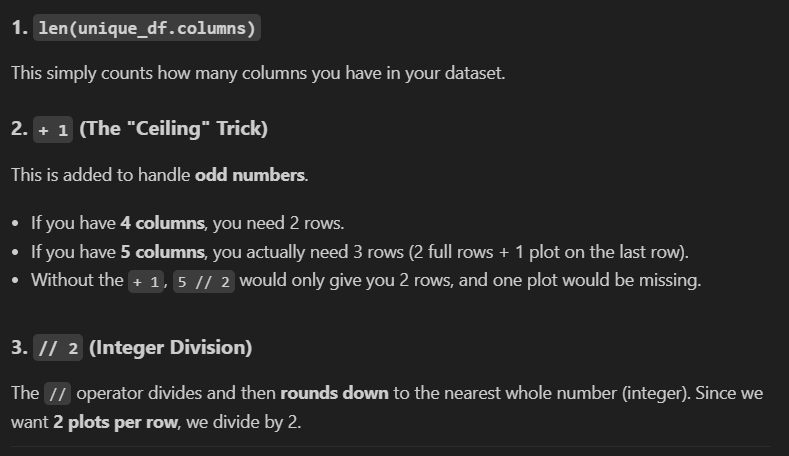

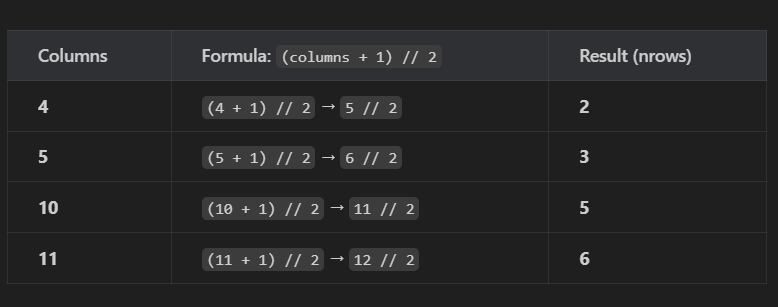

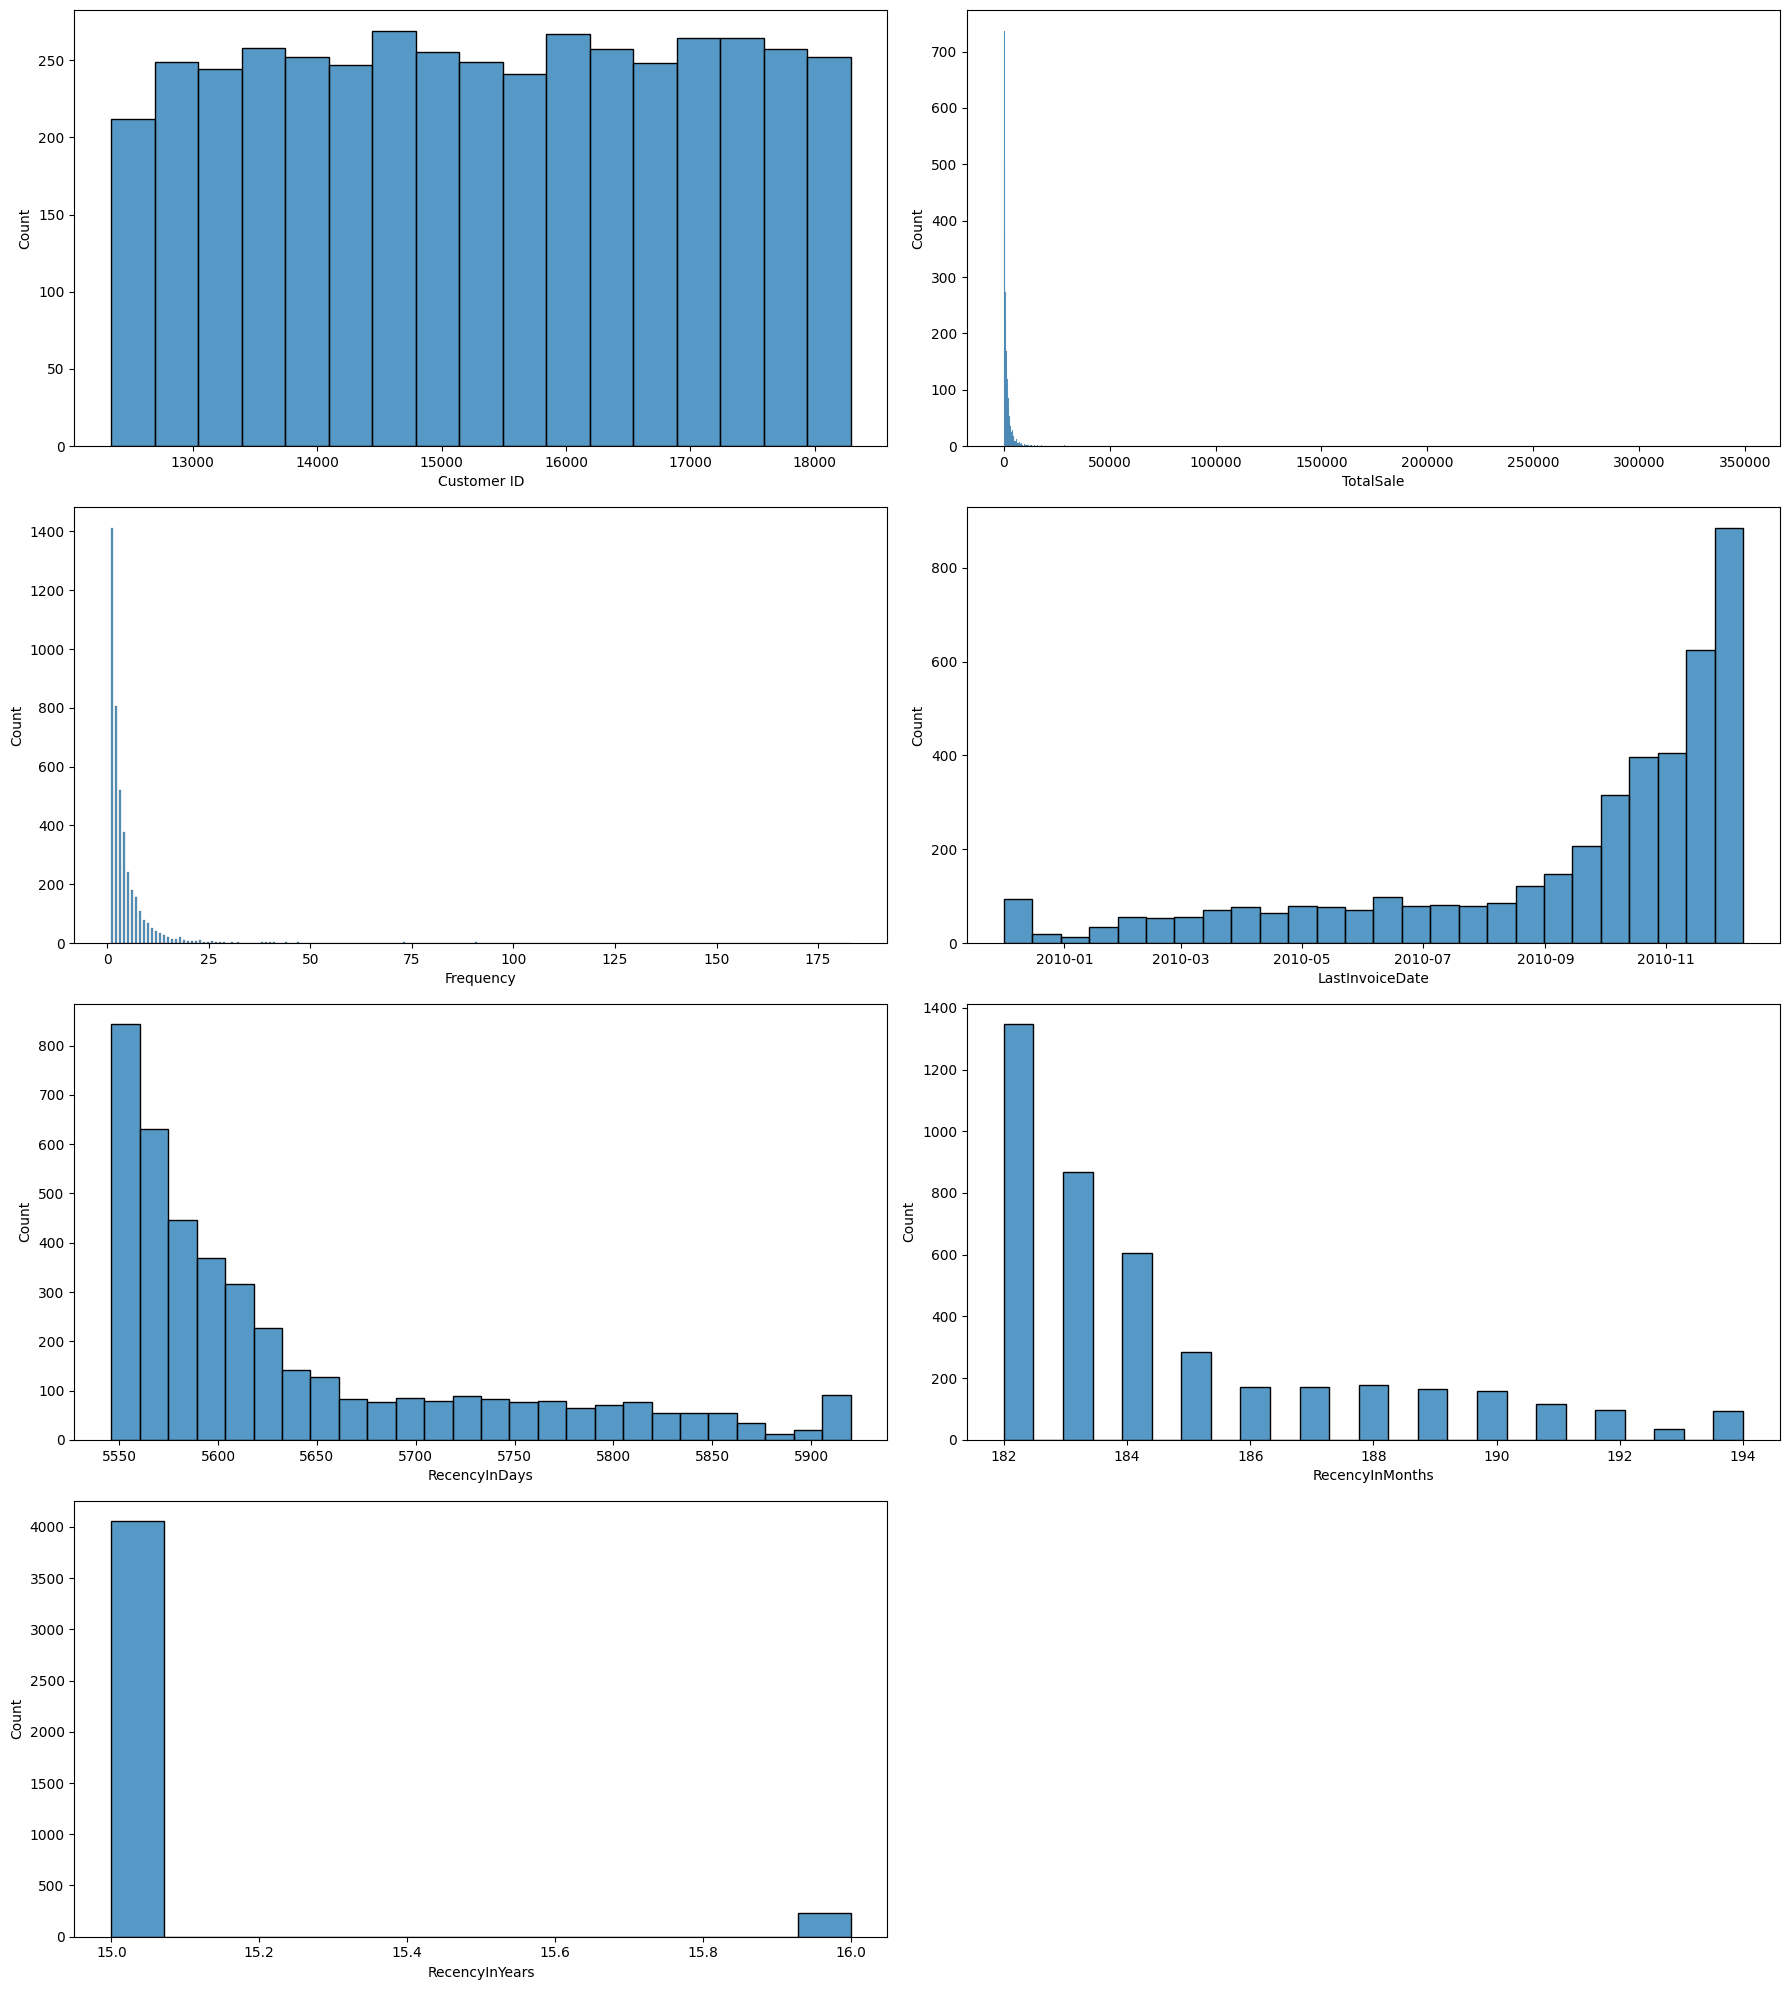

In [135]:
# plotting the data

# Calculating how many rows we need if we want 2 columns
ncols = 2
nrows = (len(data.columns) + 1) // 2 

fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 5))

# Using ravel() to flatten the 2D grid of axes into a 1D list so we can loop over it
axes = axes.ravel() 

for i, col in enumerate(data.columns):
    sns.histplot(data[col], ax=axes[i]) # Tells seaborn which subplot to use
    plt.xlabel(col)
    plt.ylabel('Count')
    
# If you have an odd number of columns, delete the empty plot space at the end
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

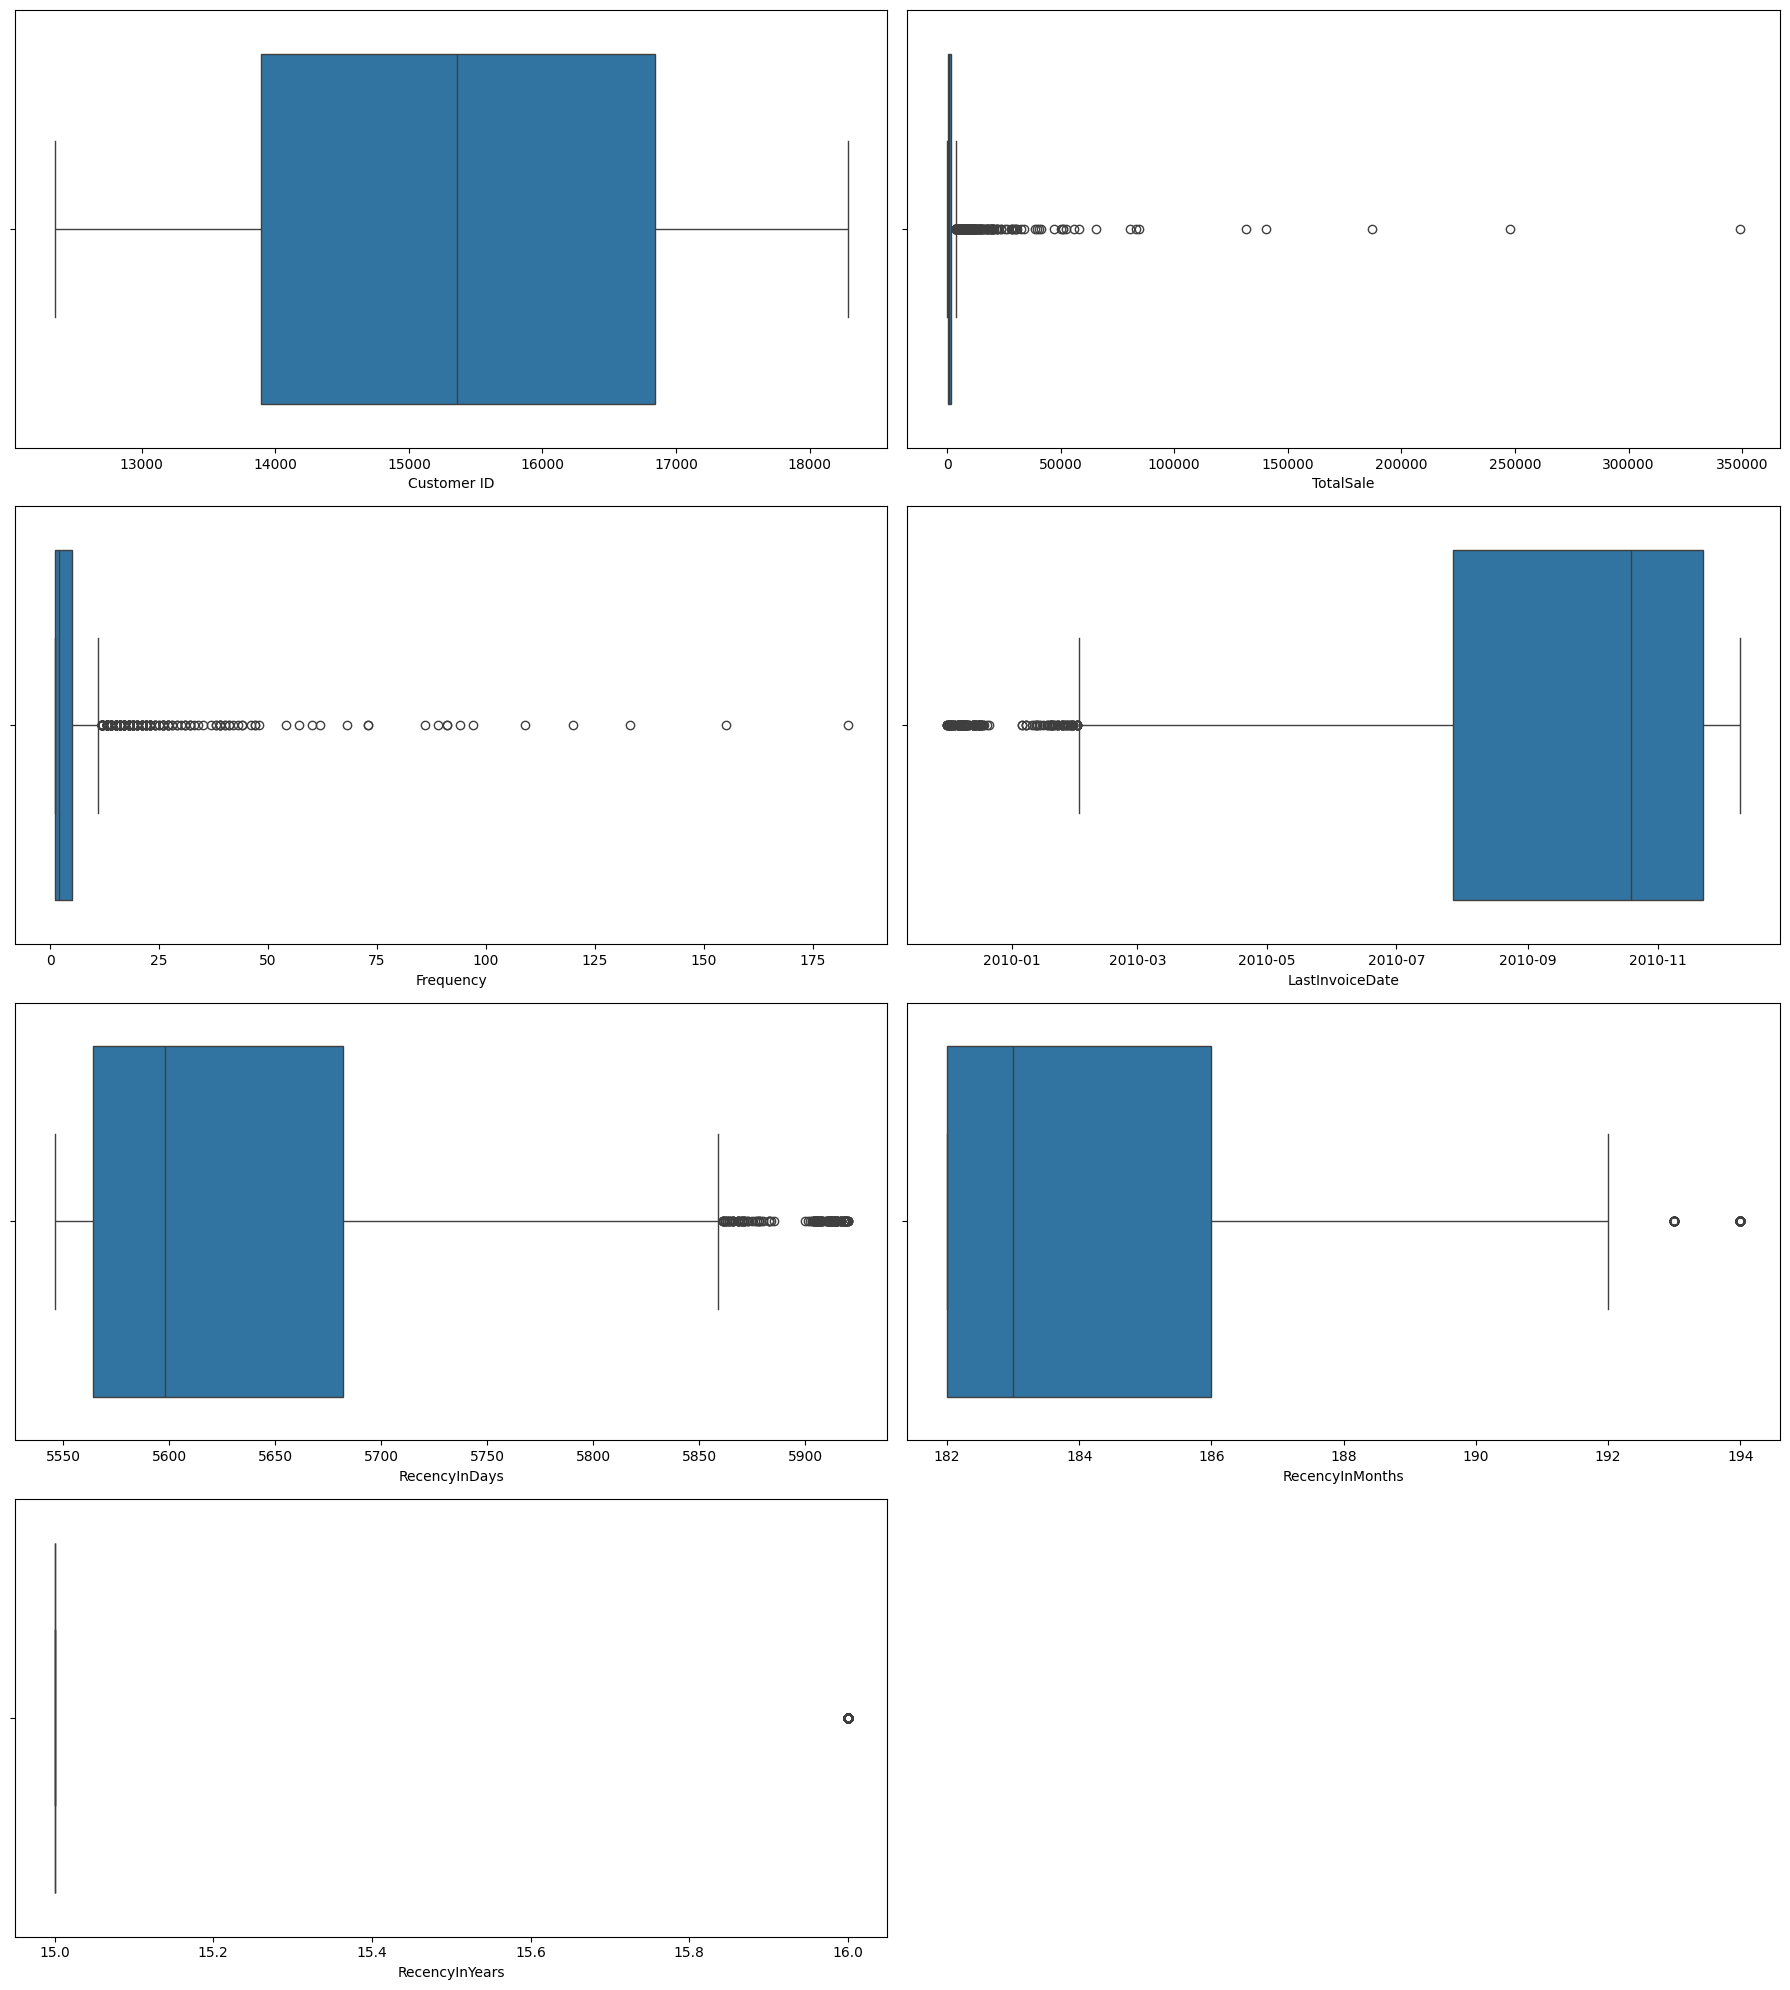

In [136]:
# plotting the data

# Calculating how many rows we need if we want 2 columns
ncols = 2
nrows = (len(data.columns) + 1) // 2 

fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 5))

# Using ravel() to flatten the 2D grid of axes into a 1D list so we can loop over it
axes = axes.ravel() 

for i, col in enumerate(data.columns):
    sns.boxplot(x=data[col], ax=axes[i]) # Tells seaborn which subplot to use
    plt.xlabel(col)
    plt.ylabel('Count')
    
# If you have an odd number of columns, delete the empty plot space at the end
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [137]:
# using IQR method to deal with outliers

for i in data.columns:
    if (i == 'Customer ID') | (i == 'LastInvoiceDate'):
        continue

    q1 = data[i].quantile(0.25)
    q3 = data[i].quantile(0.75)
    iqr = q3 - q1

    upper_limit = q3 + 1.5 * iqr
    lower_limit = q1 - 1.5 * iqr
    # Filter the data
    outliers = data[(data[i] > upper_limit) | (data[i] < lower_limit)]

    print(f"TOTAL OUTLIERS IN {i} : ", outliers.shape[0])
    print(f"mean : {outliers[i].mean().astype(int)}")
    print(f"std : {outliers[i].std()}")
    print(f"count : {outliers[i].count()}")
    print(f"min : {outliers[i].min()}")
    print(f"max : {outliers[i].max()}")
    print(f"q1 : {outliers[i].quantile(0.25)}")
    print(f"q3 : {outliers[i].quantile(0.75)}")
    print(f"iqr : {outliers[i].quantile(0.50)}")
    print("-------------------------------------------------------------")



TOTAL OUTLIERS IN TotalSale :  423
mean : 12188
std : 25830.85104517924
count : 423
min : 3802.04
max : 349164.35
q1 : 4605.94
q3 : 10273.235
iqr : 6191.32
-------------------------------------------------------------
TOTAL OUTLIERS IN Frequency :  279
mean : 23
std : 21.932936690493907
count : 279
min : 12
max : 183
q1 : 13.0
q3 : 23.0
iqr : 17.0
-------------------------------------------------------------
TOTAL OUTLIERS IN RecencyInDays :  167
mean : 5897
std : 20.496451837138274
count : 167
min : 5861
max : 5920
q1 : 5875.5
q3 : 5914.0
iqr : 5907.0
-------------------------------------------------------------
TOTAL OUTLIERS IN RecencyInMonths :  126
mean : 193
std : 0.44564916089136125
count : 126
min : 193
max : 194
q1 : 193.0
q3 : 194.0
iqr : 194.0
-------------------------------------------------------------
TOTAL OUTLIERS IN RecencyInYears :  230
mean : 16
std : 0.0
count : 230
min : 16
max : 16
q1 : 16.0
q3 : 16.0
iqr : 16.0
----------------------------------------------------

In [138]:
# from above we learned that we will be removing outliers only from TotalSale and Frequency


q1 = data['TotalSale'].quantile(0.25)
q3 = data['TotalSale'].quantile(0.75)
iqr = q3 - q1

upper_limit = q3 + 1.5 * iqr
lower_limit = q1 - 1.5 * iqr


outliers_sale = data[(data['TotalSale'] > upper_limit) | (data['TotalSale'] < lower_limit)]

# ************************************************************************************************************************

q1 = data['Frequency'].quantile(0.25)
q3 = data['Frequency'].quantile(0.75)
iqr = q3 - q1

upper_limit = q3 + 1.5 * iqr
lower_limit = q1 - 1.5 * iqr


outliers_frequency = data[(data['Frequency'] > upper_limit) | (data['Frequency'] < lower_limit)]

print(outliers_sale.shape)
print(outliers_frequency.shape)


(423, 7)
(279, 7)


In [139]:
# checking for non-outlier datas

non_outliers = data[(~data.index.isin(outliers_sale.index)) & ((~data.index.isin(outliers_frequency.index)))] 

print(non_outliers.shape[0])
non_outliers.describe()

3809


,Customer ID,TotalSale,Frequency,LastInvoiceDate,RecencyInDays,RecencyInMonths,RecencyInYears
count,3809.000000,3809.000000,3809.000000,3809,3809.000000,3809.000000,3809.000000
mean,15376.482804,885.502197,2.863481,2010-09-03 11:16:46.516146176,5643.886847,184.913363,15.059596
min,12346.000000,1.550000,1.000000,2009-12-01 10:49:00,5546.000000,182.000000,15.000000
25%,13912.000000,279.910000,1.000000,2010-07-08 14:48:00,5569.000000,182.000000,15.000000
50%,15389.000000,588.050000,2.000000,2010-10-12 16:25:00,5604.000000,184.000000,15.000000
75%,16854.000000,1269.050000,4.000000,2010-11-17 13:14:00,5701.000000,187.000000,15.000000
max,18287.000000,3788.210000,11.000000,2010-12-09 20:01:00,5920.000000,194.000000,16.000000
std,1693.199806,817.672283,2.243748,NaN,98.122137,3.240752,0.236767


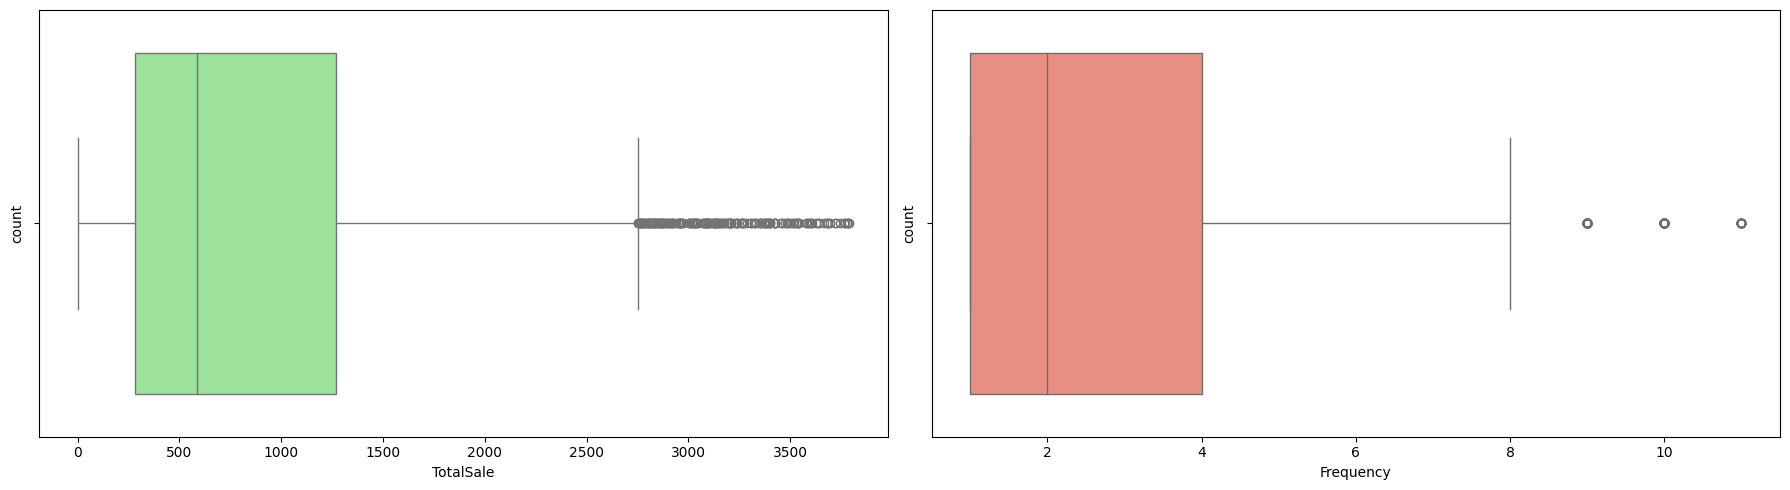

In [140]:
# plotting the non-outlier data 

plt.figure(figsize=(18, 5))

plt.subplot(121)
sns.boxplot(x=non_outliers['TotalSale'], color='lightgreen')
plt.ylabel('count')

plt.subplot(122)
sns.boxplot(x=non_outliers['Frequency'], color='salmon')
plt.ylabel('count')

plt.tight_layout()
plt.show()

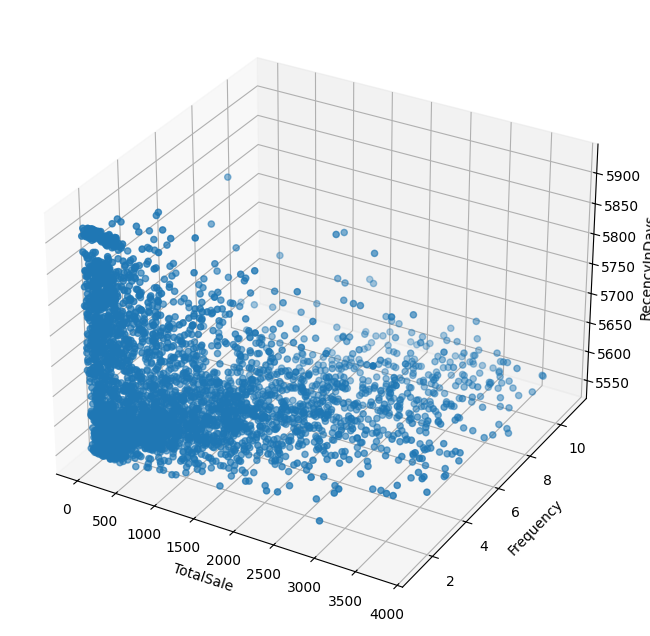

In [141]:
# making a 3D plot of the data

fig = plt.figure(figsize=(8,8))

ax = fig.add_subplot(projection='3d')

scatter = ax.scatter(non_outliers['TotalSale'], non_outliers['Frequency'], non_outliers['RecencyInDays'])

ax.set_xlabel('TotalSale')
ax.set_ylabel('Frequency')
ax.set_zlabel('RecencyInDays')


plt.show()

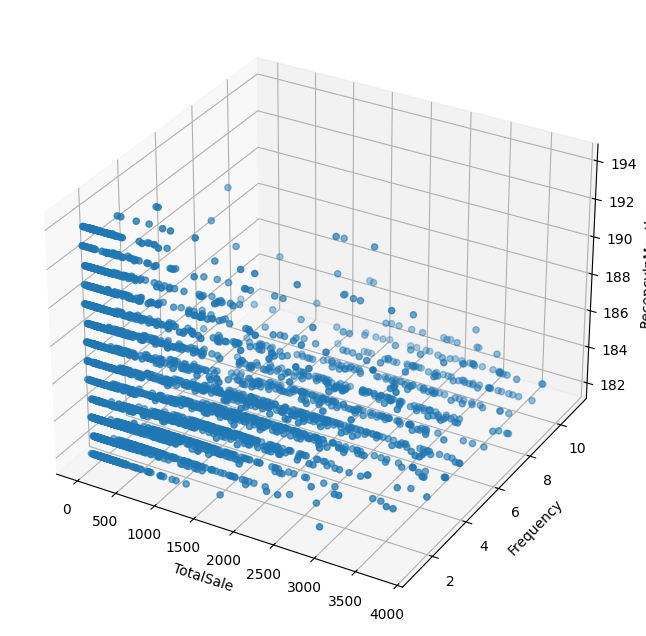

In [142]:
fig = plt.figure(figsize=(8,8))

ax = fig.add_subplot(projection='3d')

scatter = ax.scatter(non_outliers['TotalSale'], non_outliers['Frequency'], non_outliers['RecencyInMonths'])

ax.set_xlabel('TotalSale')
ax.set_ylabel('Frequency')
ax.set_zlabel('RecencyInMonths')


plt.show()

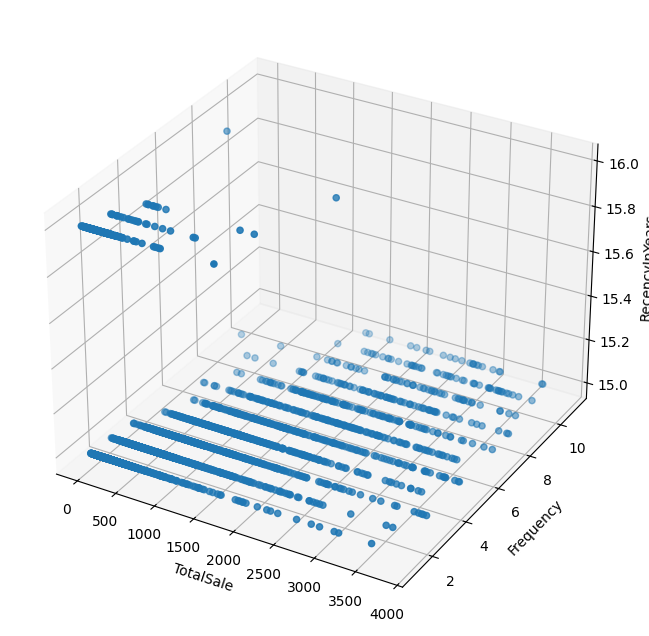

In [143]:
# making a 3D plot of the data

fig = plt.figure(figsize=(8,8))

ax = fig.add_subplot(projection='3d')

scatter = ax.scatter(non_outliers['TotalSale'], non_outliers['Frequency'], non_outliers['RecencyInYears'])  # as you can see, we have much higher sale and frequency in 15 year back compared to the 16 year back

ax.set_xlabel('TotalSale')
ax.set_ylabel('Frequency')
ax.set_zlabel('RecencyInYears')


plt.show()

In [144]:
# scaling the data
scaler = StandardScaler()
scaled_data = scaler.fit_transform(non_outliers[['TotalSale', 'Frequency', 'RecencyInDays']])
scaled_data = pd.DataFrame(scaled_data, index=non_outliers.index, columns=['TotalSale', 'Frequency', 'RecencyInDays'])

scaled_data.head()

,TotalSale,Frequency,RecencyInDays
0,-0.875945,-0.384889,0.684065
1,0.535514,-0.384889,-0.967155
2,-0.812586,-0.830631,-0.243472
3,1.633678,-0.384889,-0.559446
4,-0.715016,-0.830631,-0.885613


# **KMeans clustering**

In [145]:
# now we will be plotting elbow method to find the appropriate number of cluster required

inertia=[]
silhoutte_scores=[]

for i in range(2, 13):      # we will be choosing clusters from 2 to 12
    km = KMeans(
        n_clusters=i,
        random_state=42,
        max_iter=1000
    )
    cluster_labels = km.fit_predict(scaled_data)
    sil = silhouette_score(scaled_data, cluster_labels)

    silhoutte_scores.append(sil)
    inertia.append(km.inertia_)




Inertia values: [6174.820936504806, 3606.5294139402695, 2751.5635330595173, 2380.7587506765367, 2211.116601503053, 1894.3140043858562, 1631.5810547460878, 1558.3675782532687, 1441.954733391125, 1296.5999556076556, 1200.0725377023232]
Silhouette scores: [0.4436160581871708, 0.4585218228694714, 0.4158070043069029, 0.4026783939751255, 0.38155061616856234, 0.35842821337032826, 0.3560712340737731, 0.34192583212539873, 0.31847450109069125, 0.3278418688647694, 0.3170884381387066]


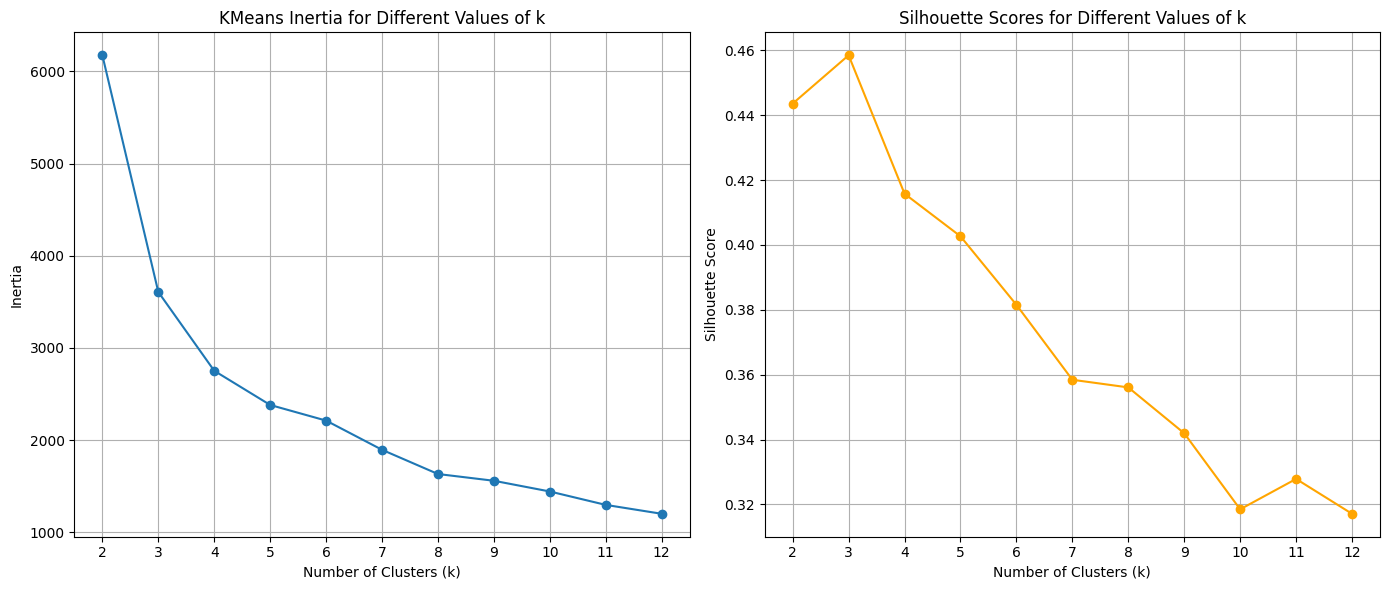

In [146]:
# plotting the graphs for kmeans and silhoutte_scores

print("Inertia values:", inertia)
print("Silhouette scores:", silhoutte_scores)

plt.figure(figsize=(14, 6))

plt.subplot(121)
plt.plot(range(2, 13), inertia, marker='o')
plt.title('KMeans Inertia for Different Values of k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.xticks(range(2, 13))
plt.grid(True)


plt.subplot(122)
plt.plot(range(2, 13), silhoutte_scores, marker='o', color='orange')
plt.title('Silhouette Scores for Different Values of k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.xticks(range(2, 13))
plt.grid(True)


plt.tight_layout()
plt.show()

### Making of the final KMeans cluster

In [147]:
km = KMeans(
    n_clusters=4,
    random_state=42,
    max_iter=1000
)

cluster_labels = km.fit_predict(scaled_data)

print(cluster_labels)


non_outliers['Cluster'] = cluster_labels
print(non_outliers.shape)
non_outliers.head()

[1 0 2 ... 1 0 0]
(3809, 8)


,Customer ID,TotalSale,Frequency,LastInvoiceDate,RecencyInDays,RecencyInMonths,RecencyInYears,Cluster
0,12346.0,169.36,2,2010-06-28 13:53:00,5711,187,15,1
1,12347.0,1323.32,2,2010-12-07 14:57:00,5549,182,15,0
2,12348.0,221.16,1,2010-09-27 14:59:00,5620,184,15,2
3,12349.0,2221.14,2,2010-10-28 08:23:00,5589,183,15,0
4,12351.0,300.93,1,2010-11-29 15:23:00,5557,182,15,2


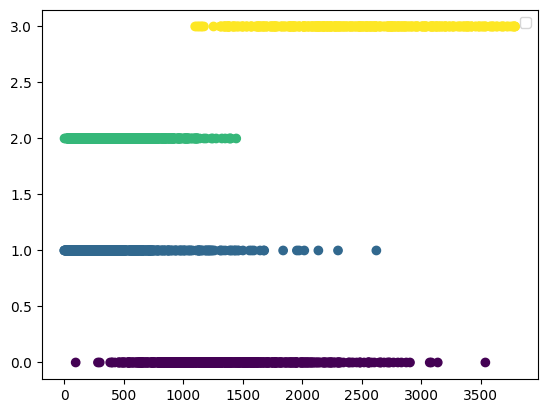

In [148]:
plt.scatter(non_outliers['TotalSale'], non_outliers['Cluster'], c=non_outliers['Cluster'])
plt.legend()
plt.show()

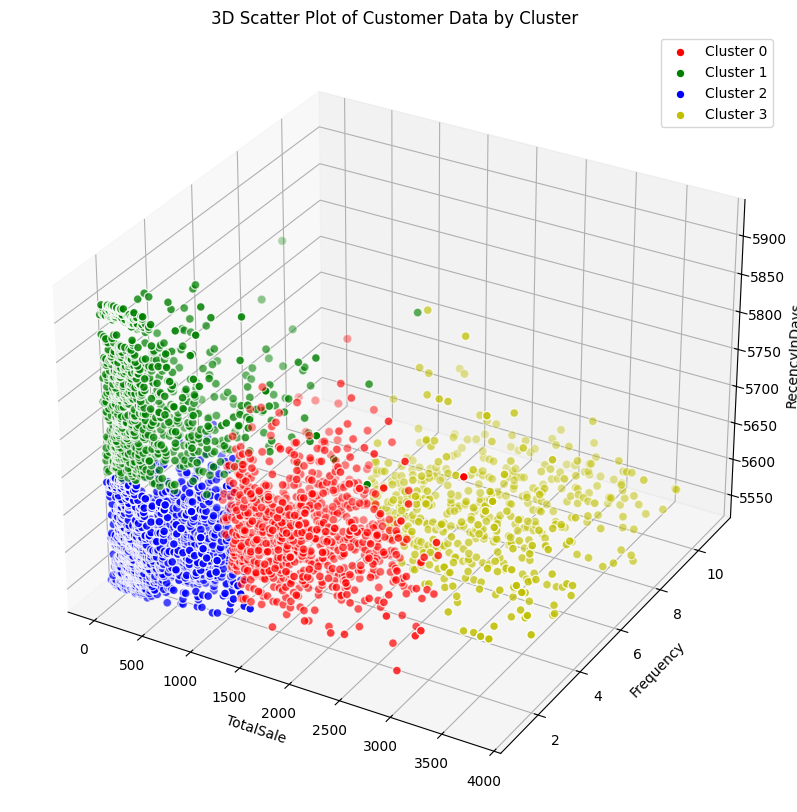

In [149]:
cluster_colors = {0: 'r', 1: 'g', 2: 'b', 3: 'y'}

fig = plt.figure(figsize=(10,10))
ax = fig.add_subplot(projection='3d')

# Plot each cluster separately to include labels for the legend
for cluster in sorted(non_outliers['Cluster'].unique()):
    subset = non_outliers[non_outliers['Cluster'] == cluster]
    ax.scatter(
        subset['TotalSale'],
        subset['Frequency'],
        subset['RecencyInDays'],
        c=cluster_colors[cluster],
        label=f'Cluster {cluster}',
        marker='o',
        edgecolor='w',
        s=40
    )

ax.set_xlabel('TotalSale')
ax.set_ylabel('Frequency')
ax.set_zlabel('RecencyInDays')

ax.set_title('3D Scatter Plot of Customer Data by Cluster')
ax.legend() # This adds the labels to the plot
plt.show()

In [150]:
# Interactive 3D Plot using Plotly
import plotly.express as px

# Create an interactive 3D scatter plot
fig = px.scatter_3d(
    non_outliers, 
    x='TotalSale', 
    y='Frequency', 
    z='RecencyInDays',
    color='Cluster',
    title='Interactive 3D Customer Segmentation',
    labels={'TotalSale': 'Total Sale', 'Frequency': 'Frequency', 'RecencyInDays': 'Recency (Days)'},
    opacity=0.7,
    color_discrete_map={0: 'red', 1: 'green', 2: 'blue', 3: 'yellow'}
)

# Improve layout
fig.update_layout(margin=dict(l=0, r=0, b=0, t=40))
fig.show()

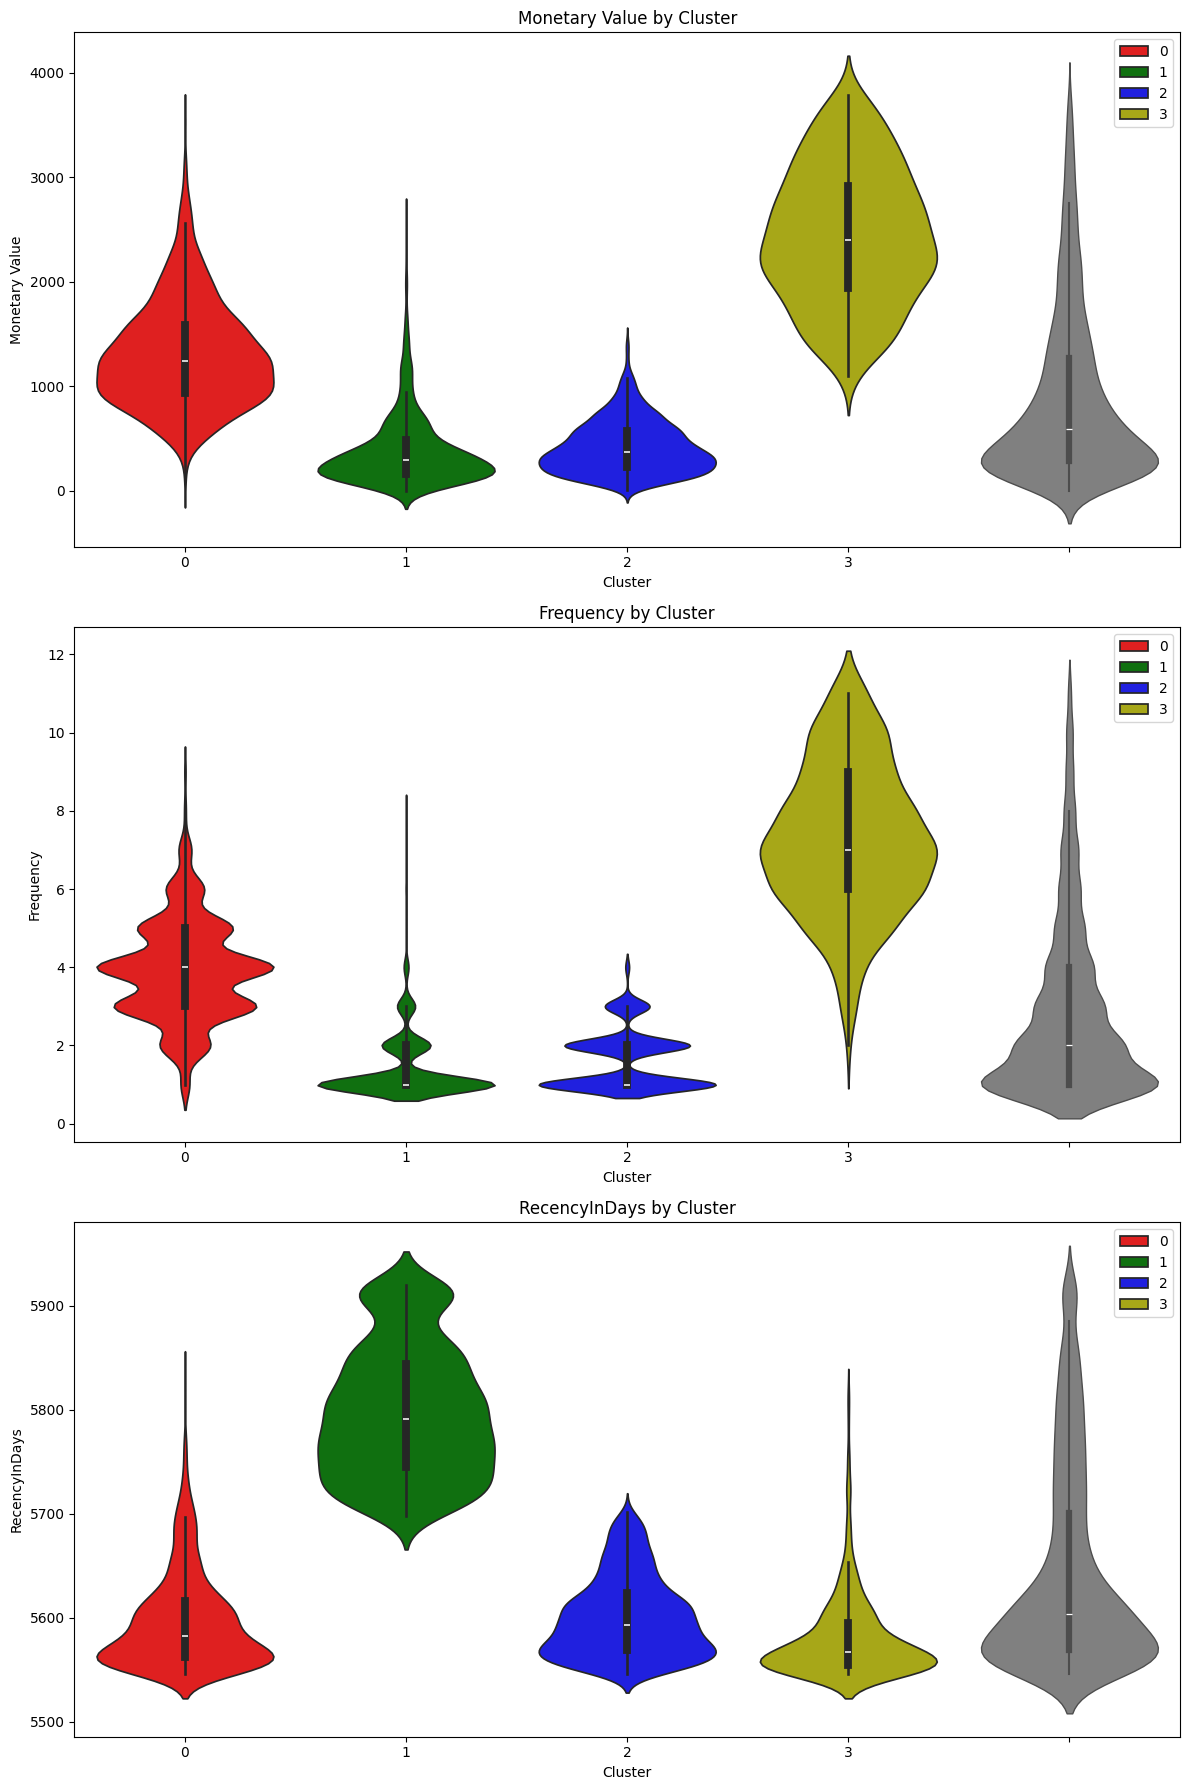

In [151]:

plt.figure(figsize=(12, 18))

plt.subplot(3, 1, 1)
sns.violinplot(x=non_outliers['Cluster'], y=non_outliers['TotalSale'], palette=cluster_colors, hue=non_outliers["Cluster"])
sns.violinplot(y=non_outliers['TotalSale'], color='gray', linewidth=1.0)
plt.title('Monetary Value by Cluster')
plt.ylabel('Monetary Value')

plt.subplot(3, 1, 2)
sns.violinplot(x=non_outliers['Cluster'], y=non_outliers['Frequency'], palette=cluster_colors, hue=non_outliers["Cluster"])
sns.violinplot(y=non_outliers['Frequency'], color='gray', linewidth=1.0)
plt.title('Frequency by Cluster')
plt.ylabel('Frequency')


plt.subplot(3, 1, 3)
sns.violinplot(x=non_outliers['Cluster'], y=non_outliers['RecencyInDays'], palette=cluster_colors, hue=non_outliers["Cluster"])
sns.violinplot(y=non_outliers['RecencyInDays'], color='gray', linewidth=1.0)
plt.title('RecencyInDays by Cluster')
plt.ylabel('RecencyInDays')

plt.tight_layout()
plt.show()

In [152]:
# Analyzing Cluster Characteristics
# This cell checks the mean values of Recency, Frequency, and TotalSale for each cluster
# to verify the segmentation rationale.

cluster_summary = non_outliers.groupby('Cluster')[['RecencyInDays', 'Frequency', 'TotalSale']].mean()
cluster_summary['Count'] = non_outliers.groupby('Cluster').size()
print("Cluster RFM Profiles (Means):")
print(cluster_summary.sort_values(by='TotalSale', ascending=False))

# Mapping the suggested names for comparison
# Cluster 0: "Retain", Cluster 1: "Re-Engage", Cluster 2: "Nurture", Cluster 3: "Reward"


Cluster RFM Profiles (Means):
         RecencyInDays  Frequency    TotalSale  Count
Cluster                                              
3          5580.694332   7.242915  2436.092091    494
0          5596.524070   3.911379  1308.624695    914
2          5600.863909   1.644430   417.954203   1499
1          5797.986696   1.429047   384.536644    902


- Cluster 0 (Blue): "Retain"
    - Rationale: This cluster represents high-value customers who purchase regularly, though not always very recently. The focus should be on retention efforts to maintain their loyalty and spending levels.
    - Action: Implement loyalty programs, personalized offers, and regular engagement to ensure they remain active.

- Cluster 1 (Orange): "Re-Engage"
    - Rationale: This group includes lower-value, infrequent buyers who haven’t purchased recently. The focus should be on re-engagement to bring them back into active purchasing behavior.
    - Action: Use targeted marketing campaigns, special discounts, or reminders to encourage them to return and purchase again.

- Cluster 2 (Green): "Nurture"
    - Rationale: This cluster represents the least active and lowest-value customers, but they have made recent purchases. These customers may be new or need nurturing to increase their engagement and spending.
    - Action: Focus on building relationships, providing excellent customer service, and offering incentives to encourage more frequent purchases.

- Cluster 3 (Red): "Reward"
    - Rationale: This cluster includes high-value, very frequent buyers, many of whom are still actively purchasing. They are your most loyal customers, and rewarding their loyalty is key to maintaining their engagement.
    - Action: Implement a robust loyalty program, provide exclusive offers, and recognize their loyalty to keep them engaged and satisfied.

Summary of - Cluster Names:
- Cluster 0 (Blue): "Retain"
- Cluster 1 (Orange): "Re-Engage"
- Cluster 2 (Green): "Nurture"
- Cluster 3 (Red): "Reward"

In [153]:
# making proper segmentation of outlieres

# 1. overlapping sale frequency outliers
outliers_overlap_idx = outliers_sale.index.intersection(outliers_frequency.index) 

# 2. sales only outliers
outliers_sale_only = outliers_sale.drop(outliers_overlap_idx)

# 3. frequency only outliers
outliers_frequency_only = outliers_frequency.drop(outliers_overlap_idx)

# 4. sales and frequency (both) outliers
# Fixed the KeyError by using the original 'outliers_sale' instead of 'outliers_sale_only'
outliers_sale_and_frequency = outliers_sale.loc[outliers_overlap_idx]

print("Overlap indices:", outliers_overlap_idx.shape) 
print("Sales only outliers:", outliers_sale_only.shape)
print("Frequency only outliers:", outliers_frequency_only.shape)
print("Both Sales & Frequency outliers:", outliers_sale_and_frequency.shape)

Overlap indices: (226,)
Sales only outliers: (197, 7)
Frequency only outliers: (53, 7)
Both Sales & Frequency outliers: (226, 7)


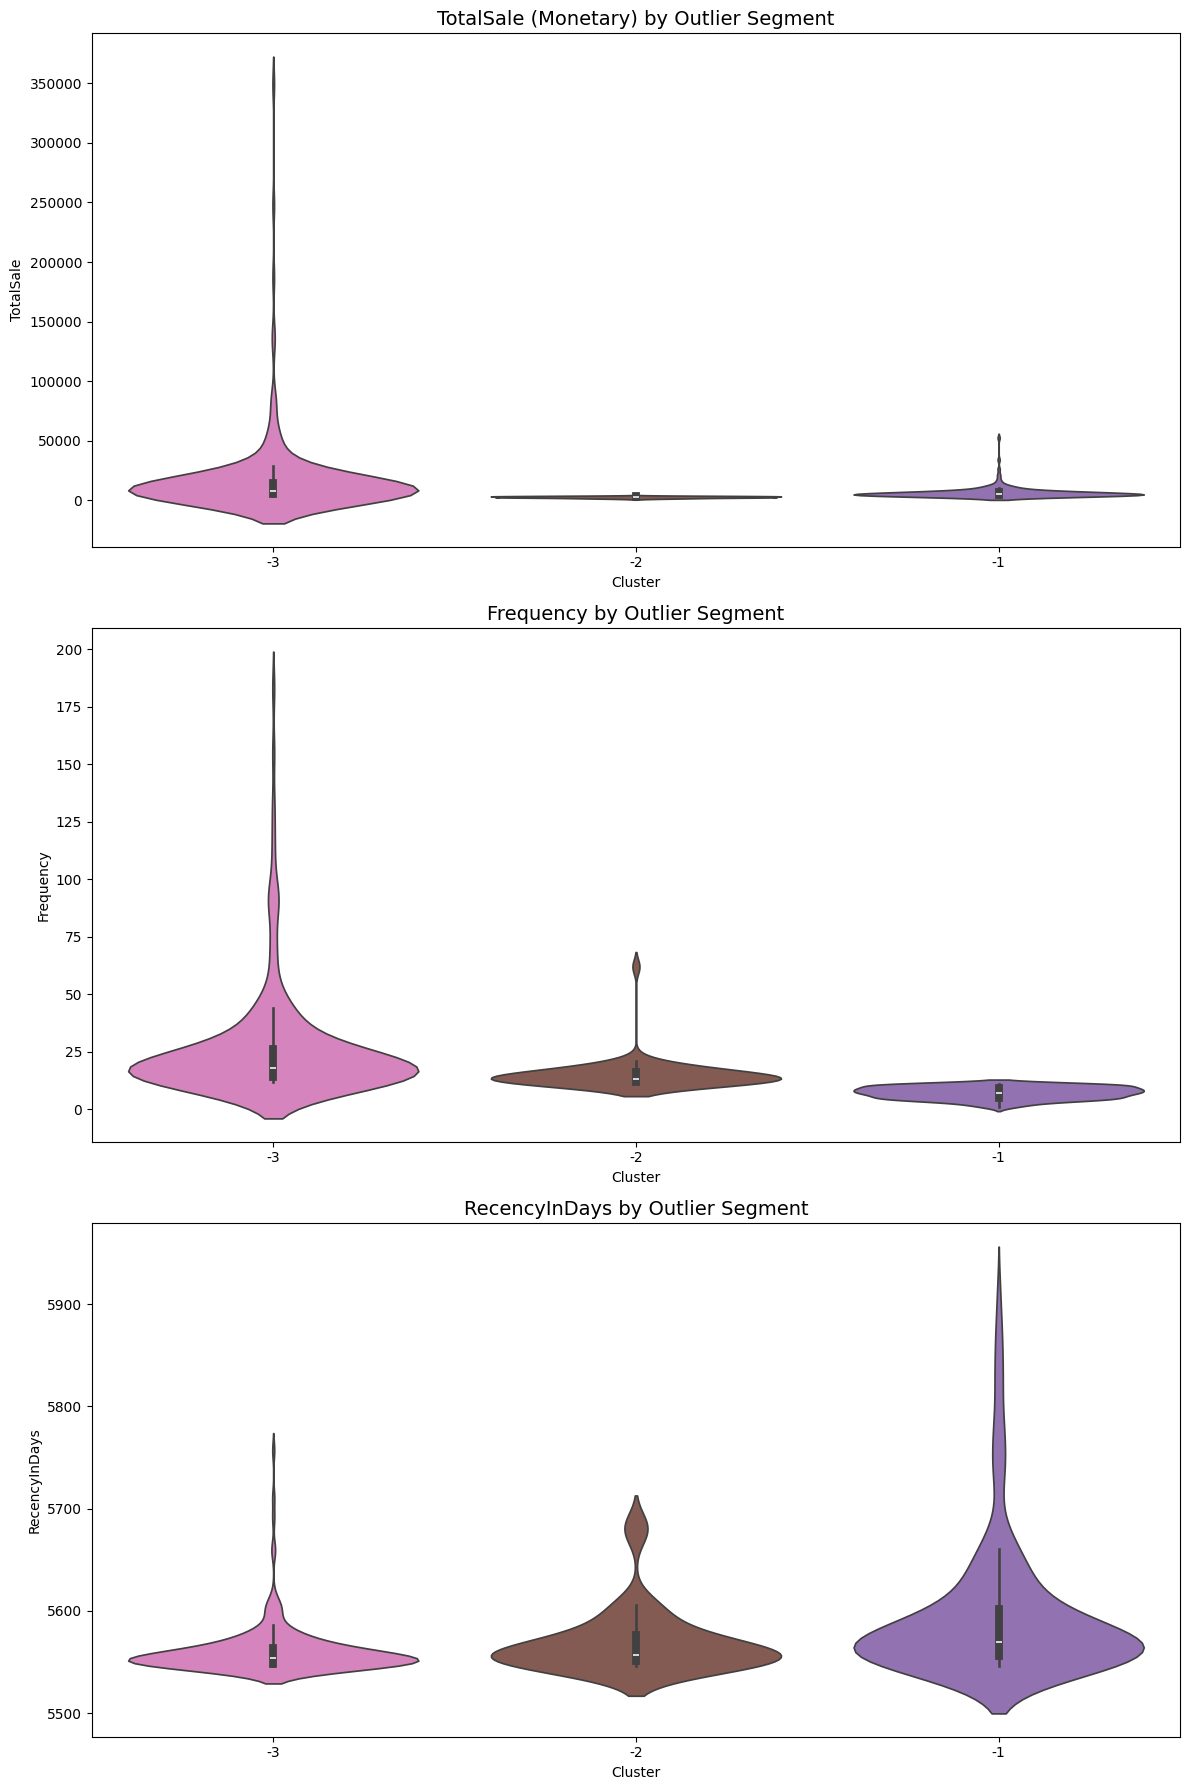

In [154]:
# 1. Assign numeric Cluster IDs to match your cluster_labels dictionary
outliers_sale_only['Cluster'] = -1
outliers_frequency_only['Cluster'] = -2
outliers_sale_and_frequency['Cluster'] = -3

# 2. Combine your specific outlier objects into one DataFrame
outlier_clusters_df = pd.concat([
    outliers_sale_only, 
    outliers_frequency_only, 
    outliers_sale_and_frequency
])

# 3. Define colors for plotting using numeric IDs
cluster_colors = {
    -1: '#9467bd', # PAMPER (Sales Only)
    -2: '#8c564b', # UPSELL (Frequency Only)
    -3: '#e377c2'  # DELIGHT (Both)
}

plt.figure(figsize=(12, 18))

# Monetary (TotalSale)
plt.subplot(3, 1, 1)
sns.violinplot(data=outlier_clusters_df, x='Cluster', y='TotalSale', 
               palette=cluster_colors, hue='Cluster', legend=False)
plt.title('TotalSale (Monetary) by Outlier Segment', fontsize=14)

# Frequency
plt.subplot(3, 1, 2)
sns.violinplot(data=outlier_clusters_df, x='Cluster', y='Frequency', 
               palette=cluster_colors, hue='Cluster', legend=False)
plt.title('Frequency by Outlier Segment', fontsize=14)

# Recency (RecencyInDays)
plt.subplot(3, 1, 3)
sns.violinplot(data=outlier_clusters_df, x='Cluster', y='RecencyInDays', 
               palette=cluster_colors, hue='Cluster', legend=False)
plt.title('RecencyInDays by Outlier Segment', fontsize=14)

plt.tight_layout()
plt.show()

In [155]:

cluster_labels = {
    0: "RETAIN",
    1: "RE-ENGAGE",
    2: "NURTURE",
    3: "REWARD",
    -1: "PAMPER",
    -2: "UPSELL",
    -3: "DELIGHT"
}

# Combine non-outliers and outliers
final_data = pd.concat([non_outliers, outlier_clusters_df])

# Map the final labels
final_data['Segment'] = final_data['Cluster'].map(cluster_labels)

print("Final Data Shape:", final_data.shape)
final_data.head(10)

Final Data Shape: (4285, 9)


,Customer ID,TotalSale,Frequency,LastInvoiceDate,RecencyInDays,RecencyInMonths,RecencyInYears,Cluster,Segment
0,12346.0,169.36,2,2010-06-28 13:53:00,5711,187,15,1,RE-ENGAGE
1,12347.0,1323.32,2,2010-12-07 14:57:00,5549,182,15,0,RETAIN
2,12348.0,221.16,1,2010-09-27 14:59:00,5620,184,15,2,NURTURE
3,12349.0,2221.14,2,2010-10-28 08:23:00,5589,183,15,0,RETAIN
4,12351.0,300.93,1,2010-11-29 15:23:00,5557,182,15,2,NURTURE
5,12352.0,343.80,2,2010-11-29 10:07:00,5557,182,15,2,NURTURE
6,12353.0,317.76,1,2010-10-27 12:44:00,5590,183,15,2,NURTURE
7,12355.0,488.21,1,2010-05-21 11:59:00,5749,188,15,1,RE-ENGAGE
8,12356.0,3126.25,3,2010-11-24 12:24:00,5562,182,15,3,REWARD
10,12358.0,2519.01,3,2010-11-29 10:56:00,5557,182,15,0,RETAIN


# **Visualisation**

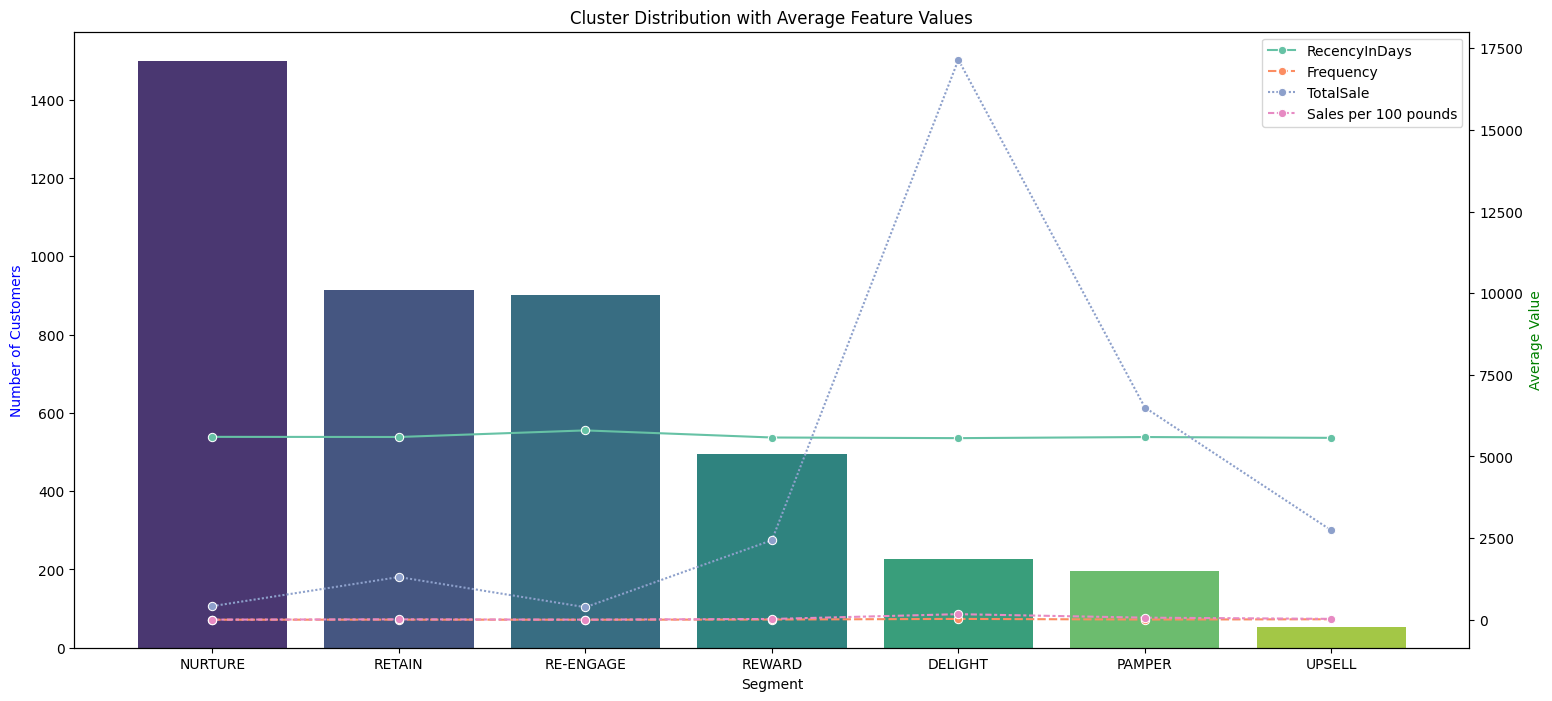

In [167]:
cluster_counts = final_data['Segment'].value_counts()
final_data['Sales per 100 pounds'] = final_data['TotalSale'] / 100.00

feature_names = final_data.groupby('Segment')[['RecencyInDays', 'Frequency', 'TotalSale', 'Sales per 100 pounds']].mean()

fig, ax1 = plt.subplots(figsize=(18, 8))

sns.barplot(x=cluster_counts.index, y=cluster_counts.values, ax=ax1, palette='viridis', hue=cluster_counts.index)
ax1.set_ylabel('Number of Customers', color='b')
ax1.set_title('Cluster Distribution with Average Feature Values')

ax2 = ax1.twinx()

sns.lineplot(data=feature_names, ax=ax2, palette='Set2', marker='o')
ax2.set_ylabel('Average Value', color='g')

plt.show()
